# Clustering choices: which events belong to one electron

One electron fires a few neighboring pixels within a tick or two. Clustering joins those events
back together, and Kronos does it with one rule:

> Two events belong together when they are on the **same or an edge-adjacent pixel** and within
> **`dt_max = 1` tick** of each other. A cluster is every event linked by a chain of such pairs.

Two choices hide in that rule, the **neighborhood** (which pixels count as neighbors) and the **time
window** `dt_max`. Each can go wrong in two directions:

* too narrow, and one electron is **split** into several clusters;
* too wide, and two electrons that land close together are **merged** into one.

Each also costs time, because every event looks up every pixel of its neighborhood. This notebook
shows how the clustering works, measures what each choice does to accuracy and to speed on a real
run, and explains why Kronos uses edge neighbors and `dt_max = 1`.

**Contents**

1. How Kronos finds clusters: one pass with union-find
2. A real sample
3. What belongs together, measured without clustering
4. Sweeping the choices
5. Why at least one tick: timewalk
6. An error budget with a known answer
7. The clusters that change
8. Speed
9. Where we landed

In [1]:
import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, TwoSlopeNorm
from matplotlib.patches import Polygon, Rectangle
from plot_style import BLUE, DIVERGING, GRID, INK, INK_2, MUTED, ORANGE, PANEL, SEQUENTIAL, SERIES, SURFACE, YELLOW, no_grid
from sklearn.cluster import DBSCAN

from kronos.cluster import _find, label_events, summarize_clusters
from kronos.events import concat, event_columns, fine_columns, fine_toa
from kronos.sort import merge_sort

%matplotlib ipympl

## 1. How Kronos finds clusters

Comparing every pair of events costs O(n²), hopeless for 10⁹ events. Because the events arrive in
time order (notebook 01), one pass is enough. `label_events` walks the events in order and keeps
two things:

* **`latest`**: an image the size of the detector holding, for every pixel, the index of the most
  recent event on it (−1 if none yet);
* **`parent`**: a *union-find* forest. Every event starts as its own cluster; `find(i)` follows
  parents to the cluster's root, and joining two clusters points one root at the other. The earlier
  event always stays the root, so each root is its cluster's first event.

For each new event *i*: look at the `latest` event *j* on each pixel of *i*'s neighborhood; if
`toa[i] − toa[j] ≤ dt_max`, join their clusters; then write *i* into `latest`.

**Why only the latest event per pixel?** If pixel *p* fired at *a* < *b* and the new event comes at
*t*, and *a* is close enough (`t − a ≤ dt_max`), then so is *b*, and *a* is already in *b*'s cluster.
Linking to *b* alone gives the same clusters, so one pass is enough.

Here is the loop in plain Python on a toy detector (10 × 10 pixels, 55 electrons that each fire 1–4
edge-adjacent pixels at `t0` or `t0 + 1`), checked against `label_events`:

In [2]:
SIZE, T_END, N_ELECTRONS, DT_MAX = 10, 100, 55, 1
EDGE_NEIGHBORS = [(1, 0), (-1, 0), (0, 1), (0, -1)]
NEIGHBORS = [(0, 0)] + EDGE_NEIGHBORS  # own pixel + 4 edge neighbors

rng = np.random.default_rng(4)
electrons = []
while len(electrons) < N_ELECTRONS:
    t0 = int(rng.integers(1, T_END))
    cx, cy = (int(v) for v in rng.integers(0, SIZE, 2))
    n_pixels = 1 + rng.choice(4, p=[0.36, 0.52, 0.09, 0.03])
    pixels = [(cx, cy)]
    for k in rng.permutation(4):
        dx, dy = EDGE_NEIGHBORS[k]
        if len(pixels) < n_pixels and 0 <= cx + dx < SIZE and 0 <= cy + dy < SIZE:
            pixels.append((cx + dx, cy + dy))
    if not any(abs(t0 - t) <= 4 and abs(px - qx) <= 2 and abs(py - qy) <= 2 for t, others in electrons for qx, qy in others for px, py in pixels):
        electrons.append((t0, pixels))
toy = np.array(sorted((t0 + int(rng.integers(0, 2)), px, py) for t0, pixels in electrons for px, py in pixels))
toa, x, y = toy.T

parent = list(range(len(toa)))
latest = np.full((SIZE, SIZE), -1)  # latest event index on each pixel
steps = []
for i in range(len(toa)):
    links = []
    for dx, dy in NEIGHBORS:
        px, py = x[i] + dx, y[i] + dy
        if 0 <= px < SIZE and 0 <= py < SIZE and latest[py, px] >= 0 and toa[i] - toa[latest[py, px]] <= DT_MAX:
            j = latest[py, px]
            a, b = i, j
            while parent[a] != a:
                a = parent[a]
            while parent[b] != b:
                b = parent[b]
            parent[max(a, b)] = min(a, b)  # the earlier event stays root
            links.append(int(j))
    steps.append({'latest': latest.copy(), 'links': links})
    latest[y[i], x[i]] = i
roots = []
for i in range(len(toa)):
    r = i
    while parent[r] != r:
        r = parent[r]
    roots.append(r)
traced = np.unique(roots, return_inverse=True)[1]
labels = label_events(x, y, toa, DT_MAX)
print(
    f'{len(toa)} events -> {labels.max() + 1} clusters ({N_ELECTRONS} electrons); plain-Python loop gives the same labels as label_events: {np.array_equal(traced, labels)}'
)

110 events -> 55 clusters (55 electrons); plain-Python loop gives the same labels as label_events: True


Eight consecutive steps. Each panel shows the `latest` image just before event *i* is added,
colored by how long ago each pixel last fired (dark blue: this tick, light blue: one tick ago, both
within `dt_max`; gray: too old). The orange square is the new event with its neighborhood dashed;
orange lines are the links it makes, and no link means a new cluster.

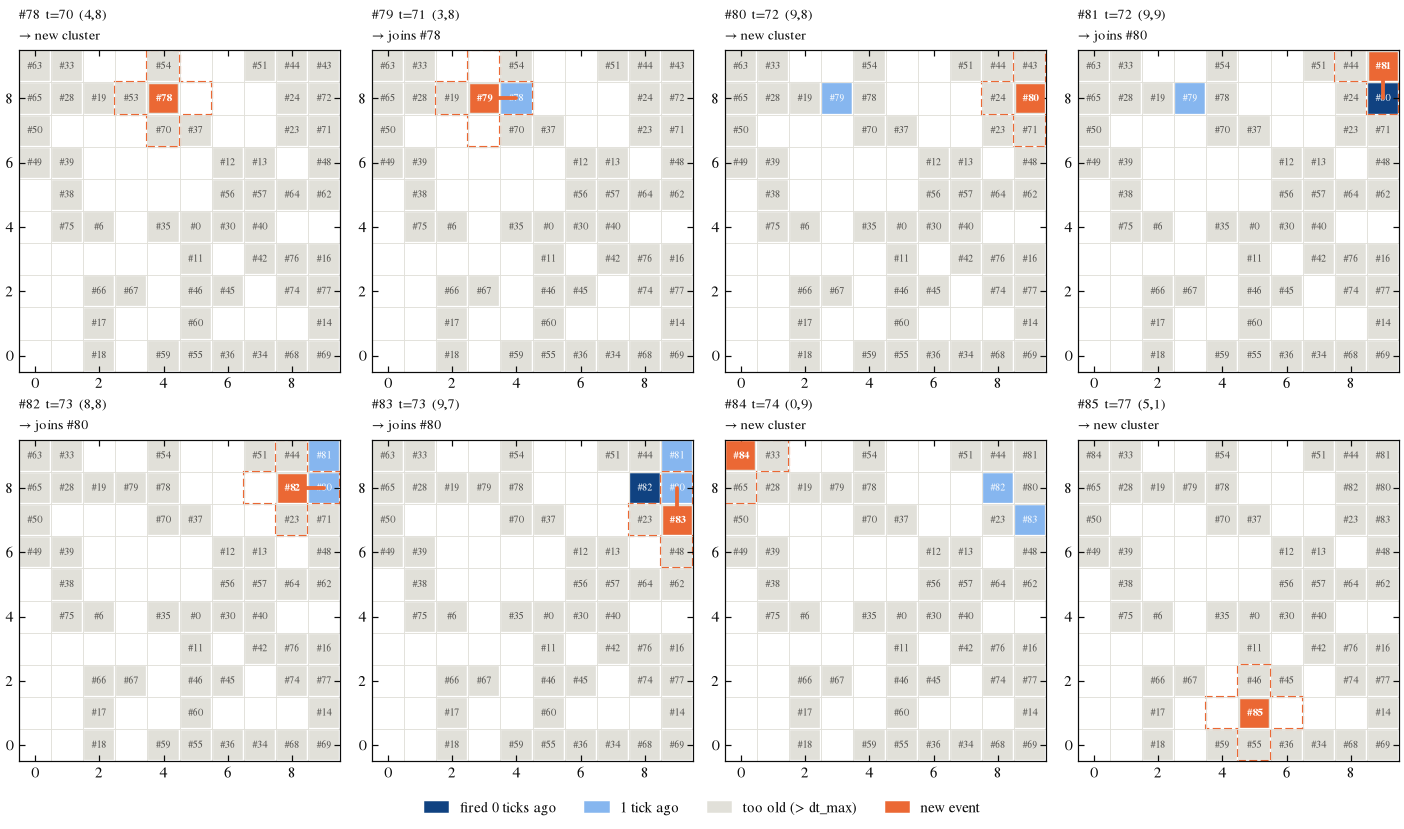

In [3]:
AGE_COLORS = ['#104281', '#86b6ef']  # fired 0 or 1 tick ago
CROSS = [
    (-0.5, -1.5),
    (0.5, -1.5),
    (0.5, -0.5),
    (1.5, -0.5),
    (1.5, 0.5),
    (0.5, 0.5),
    (0.5, 1.5),
    (-0.5, 1.5),
    (-0.5, 0.5),
    (-1.5, 0.5),
    (-1.5, -0.5),
    (-0.5, -0.5),
]
first_big = np.flatnonzero(np.bincount(labels)[labels] == 4)[0]
fig, axes = plt.subplots(2, 4, figsize=(13, 7.6))
for ax, i in zip(axes.flat, range(first_big - 2, first_big + 6)):
    for (py, px), j in np.ndenumerate(steps[i]['latest']):
        if j >= 0:
            age = toa[i] - toa[j]
            ax.add_patch(Rectangle((px - 0.5, py - 0.5), 1, 1, color=AGE_COLORS[age] if age <= DT_MAX else GRID, ec=SURFACE, lw=1.5))
            ax.text(px, py, f'#{j}', ha='center', va='center', fontsize=6.5, color='white' if age <= DT_MAX else INK_2)
    ax.add_patch(Polygon([(x[i] + cx, y[i] + cy) for cx, cy in CROSS], fill=False, ec=ORANGE, lw=1.4, ls='--'))
    for j in steps[i]['links']:
        ax.plot([x[i], x[j]], [y[i], y[j]], color=ORANGE, lw=2.5, solid_capstyle='round', zorder=4)
    ax.add_patch(Rectangle((x[i] - 0.42, y[i] - 0.42), 0.84, 0.84, color=ORANGE, zorder=5))
    ax.text(x[i], y[i], f'#{i}', ha='center', va='center', fontsize=7, color='white', weight='bold', zorder=6)
    joined = ', '.join(f'#{j}' for j in steps[i]['links'])
    ax.set_title(f'#{i}  t={toa[i]}  ({x[i]},{y[i]})\n→ {"joins " + joined if joined else "new cluster"}', fontsize=9, weight='normal')
    ax.set(xlim=(-0.5, SIZE - 0.5), ylim=(-0.5, SIZE - 0.5), aspect='equal')
    ax.set_xticks(np.arange(-0.5, SIZE), minor=True), ax.set_yticks(np.arange(-0.5, SIZE), minor=True)
    ax.grid(False)
    ax.grid(which='minor', color=GRID, linewidth=0.6)
    ax.tick_params(which='minor', length=0, labelsize=7)
handles = [Rectangle((0, 0), 1, 1, color=c) for c in (*AGE_COLORS, GRID, ORANGE)]
fig.legend(handles, ['fired 0 ticks ago', '1 tick ago', 'too old (> dt_max)', 'new event'], ncol=4, loc='lower center')
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

**The package version** runs the same loop, compiled with numba, with two additions:

* **All cores.** A part is cut into time slices, each labeled on its own thread. A link across a cut
  joins two events within `dt_max` of each other, so both lie within `dt_max` of the cut; rerunning the
  loop on that thin window links every cluster across it. The labels are identical to one long pass.
* **Parts.** Clustering runs inside the sorting pass (notebook 01). A cluster with an event in the
  last `dt_max` ticks of a part may continue into the next one, so it is carried over and finished
  there (`cluster_parts`, `cluster_tables`).

The work per event is one lookup per neighborhood pixel, so the neighborhood sets the cost; the time
window costs nothing by itself. The rest of the notebook is about what the two choices do to the
clusters.

## 2. A real sample

The first five parts of the test run, ~25 M events and 0.3 s of beam.

24,969,986 events over 0.29 s: 2.13 events per tick on the whole chip
even the busiest pixels fire once per 9,348 ticks


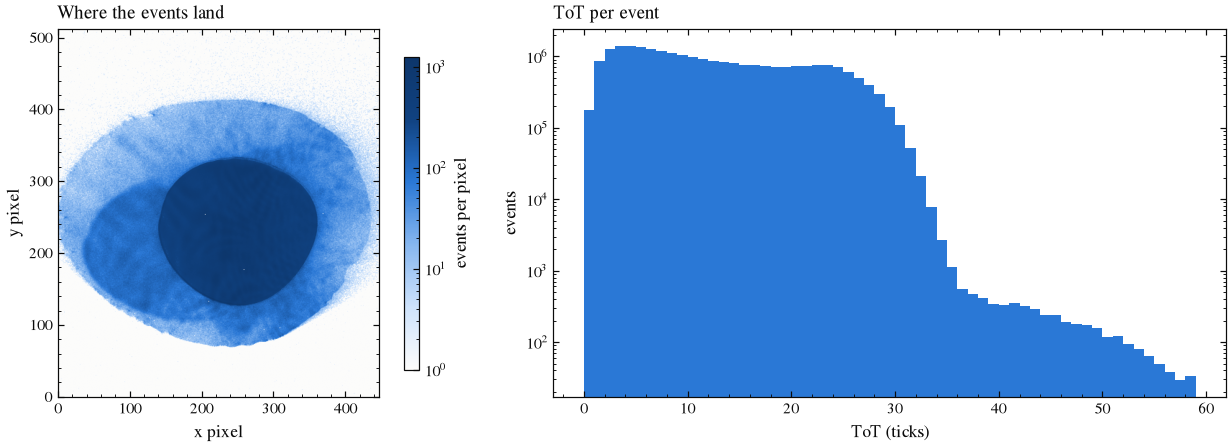

In [4]:
data_directory = Path('/Users/7c2/Desktop/Projects/TimePix/data/2026_09_30_tp4_firsttry')
files = sorted(data_directory.glob('austin_test_*.h5'))
WIDTH, HEIGHT = 448, 512
PREVIOUS_DT, CHOSEN_DT = 2, 1  # the earlier default (with the 3 x 3 square) and the one chosen here (with edge neighbors)

parts = merge_sort(files, columns=event_columns + fine_columns)
raw = concat([next(parts) for _ in range(5)])
del parts
ev = {
    'x': raw['x'].astype(np.int32),
    'y': raw['y'].astype(np.int32),
    'toa': raw['toa'].astype(np.int64),
    'tot': raw['tot'].astype(np.int64),
    'tf': fine_toa(raw),
}
del raw
n_events = len(ev['toa'])
span = int(ev['toa'][-1] - ev['toa'][0])
beam = np.zeros((HEIGHT, WIDTH))
np.add.at(beam, (ev['y'], ev['x']), 1)
rate = beam / span
print(f'{n_events:,} events over {span * 25e-9:.2f} s: {n_events / span:.2f} events per tick on the whole chip')
print(f'even the busiest pixels fire once per {1 / rate.max():,.0f} ticks')

fig, (ax_beam, ax_tot) = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={'width_ratios': [1, 1.4]})
shown = ax_beam.imshow(np.maximum(beam, 1), origin='lower', cmap=SEQUENTIAL, norm=LogNorm())
fig.colorbar(shown, ax=ax_beam, shrink=0.85, label='events per pixel')
ax_beam.set(title='Where the events land', xlabel='x pixel', ylabel='y pixel')
ax_beam.grid(False)
ax_tot.hist(ev['tot'], bins=np.arange(0, 60), color=BLUE, log=True)
ax_tot.set(title='ToT per event', xlabel='ToT (ticks)', ylabel='events')
plt.tight_layout()
plt.show()

On the scale of a cluster the detector is nearly empty, so accidental coincidences will be rare. The
rest of the notebook puts numbers on that.

## 3. What belongs together, measured without clustering

Before choosing a rule, measure where events of one electron actually are relative to each other.
For every pair of events (`j` earlier than `i`) within ±4 pixels and 160 ticks, count the offset
`(dx, dy, dt)`. Unrelated events give a flat floor (measured at `dt` = 100–160 ticks). The ratio
`g` of pairs to the floor is 1 for chance coincidences and ≫ 1 where events belong together.

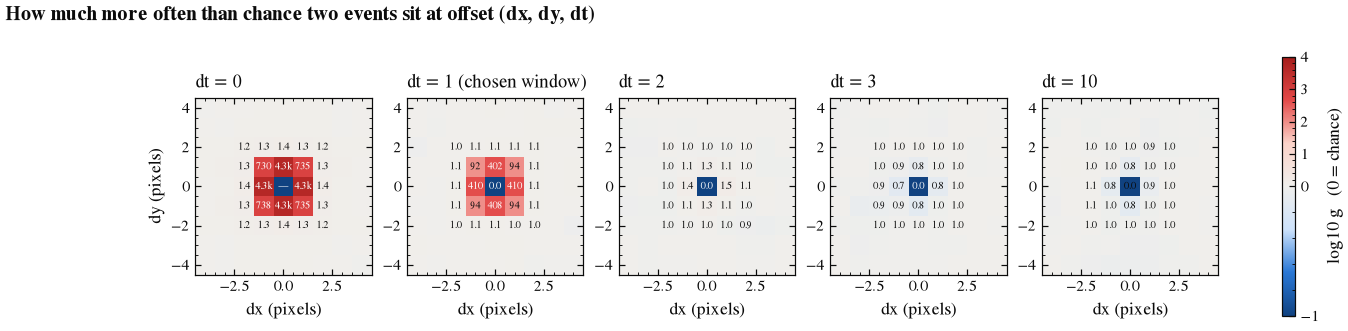

In [5]:
@numba.njit(cache=True)
def pair_histogram(x, y, t, radius, max_dt):
    hist = np.zeros((max_dt + 1, 2 * radius + 1, 2 * radius + 1), np.int64)
    lo = 0
    for i in range(len(t)):
        while t[i] - t[lo] > max_dt:
            lo += 1
        for j in range(lo, i):
            dx, dy = x[i] - x[j], y[i] - y[j]
            if -radius <= dx <= radius and -radius <= dy <= radius:
                hist[t[i] - t[j], dy + radius, dx + radius] += 1
    return hist


R_PAIR, T_PAIR = 4, 160
H = pair_histogram(ev['x'], ev['y'], ev['toa'], R_PAIR, T_PAIR).astype(float)
floor = H[100:].mean(axis=0)  # chance level per offset and tick
g = H / floor
g[0] = (H[0] + H[0, ::-1, ::-1]) / floor  # at dt = 0 the pair order is arbitrary: fold the two signs
dx_grid, dy_grid = np.meshgrid(np.arange(-R_PAIR, R_PAIR + 1), np.arange(-R_PAIR, R_PAIR + 1))
cheb = np.maximum(abs(dx_grid), abs(dy_grid))

show_dt = [0, 1, 2, 3, 10]
fig, axes = plt.subplots(1, len(show_dt), figsize=(15, 3.4))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=4)
for ax, dt in zip(axes, show_dt):
    lg = np.log10(np.maximum(g[dt], 1e-3))
    shown = ax.imshow(lg, cmap=DIVERGING, norm=norm, origin='lower', extent=(-R_PAIR - 0.5, R_PAIR + 0.5, -R_PAIR - 0.5, R_PAIR + 0.5))
    for (r, c), v in np.ndenumerate(g[dt]):
        if cheb[r, c] <= 2:
            text = '—' if (r == c == R_PAIR and dt == 0) else (f'{v / 1e3:.1f}k' if v >= 1000 else f'{v:.0f}' if v >= 10 else f'{v:.1f}')
            ax.text(dx_grid[r, c], dy_grid[r, c], text, ha='center', va='center', fontsize=6.5, color='white' if abs(lg[r, c]) > 2 else INK)
    ax.set_title(f'dt = {dt}' + (' (chosen window)' if dt == CHOSEN_DT else ''))
    ax.set_xlabel('dx (pixels)')
    ax.grid(False)
axes[0].set_ylabel('dy (pixels)')
fig.colorbar(shown, ax=axes, shrink=0.9, label='log10 g   (0 = chance)')
fig.suptitle('How much more often than chance two events sit at offset (dx, dy, dt)', x=0.01, ha='left', fontweight='bold')
plt.show()

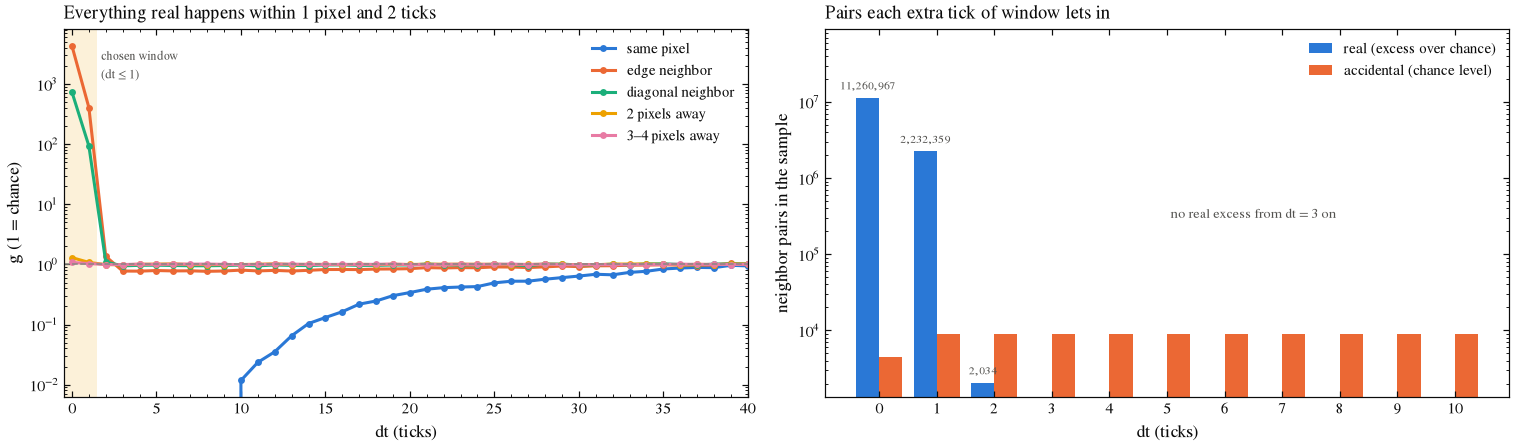

In [6]:
rings = {
    'same pixel': cheb == 0,
    'edge neighbor': abs(dx_grid) + abs(dy_grid) == 1,
    'diagonal neighbor': (abs(dx_grid) == 1) & (abs(dy_grid) == 1),
    '2 pixels away': cheb == 2,
    '3–4 pixels away': cheb >= 3,
}
fig, (ax_g, ax_pairs) = plt.subplots(1, 2, figsize=(14, 4.3))
for k, (name, mask) in enumerate(rings.items()):
    curve = H[:, mask].sum(1) / floor[mask].sum()
    curve[0] = g[0][mask].mean() if name != 'same pixel' else np.nan
    ax_g.plot(np.arange(41), curve[:41], marker='o', ms=3.5, lw=2, color=SERIES[k], label=name)
ax_g.axhline(1, color=MUTED, lw=1, ls='--')
ax_g.axvspan(-0.5, CHOSEN_DT + 0.5, color=YELLOW, alpha=0.15, lw=0)
ax_g.text(CHOSEN_DT + 0.7, 2e3, 'chosen window\n(dt ≤ 1)', color=INK_2, fontsize=8, va='center')
ax_g.set(yscale='log', xlabel='dt (ticks)', ylabel='g (1 = chance)', xlim=(-0.5, 40), title='Everything real happens within 1 pixel and 2 ticks')
ax_g.legend(loc='upper right')

near = cheb == 1  # the 8 pixels around
chance_near = np.full(T_PAIR + 1, floor[near].sum())
chance_near[0] /= 2  # dt = 0 counts each pair once
excess = H[:, near].sum(1) - chance_near
show = np.arange(0, 11)
ax_pairs.bar(show - 0.2, np.where(excess[show] > 0, excess[show], np.nan), width=0.4, color=BLUE, label='real (excess over chance)')
ax_pairs.bar(show + 0.2, chance_near[show], width=0.4, color=ORANGE, label='accidental (chance level)')
for dt in show[:3]:
    ax_pairs.text(dt - 0.2, excess[dt] * 1.3, f'{excess[dt]:,.0f}', ha='center', fontsize=7.5, color=INK_2)
ax_pairs.text(6.5, 3e5, 'no real excess from dt = 3 on', ha='center', fontsize=9, color=INK_2)
ax_pairs.set(yscale='log', xticks=show, xlabel='dt (ticks)', ylabel='neighbor pairs in the sample', title='Pairs each extra tick of window lets in')
ax_pairs.set_ylim(top=excess[0] * 8)  # room for the count labels
ax_pairs.xaxis.minorticks_off()
ax_pairs.legend(loc='upper right')
plt.tight_layout()
plt.show()

* **Space:** at dt = 0–1, edge neighbors are thousands of times above chance and diagonals hundreds.
  Two pixels away is back at chance: **charge reaches only the nearest pixels**. Left/right and
  up/down are the same, so x and y need no different treatment.
* **Time:** almost all real pairs are at dt = 0 or 1. The dt = 2 tick still holds a few thousand real
  pairs, about as many as the accidental ones it lets in. From dt = 3 on, a wider window only adds
  accidentals.
* Edge neighbors and the same pixel dip *below* chance after a hit: those pixels are busy for their
  ToT and cannot catch the next electron.

## 4. Sweeping the choices

Now cluster the sample with 17 time windows and five neighborhoods, using a copy of the package's
algorithm that accepts any neighborhood (and the fine-time cut of section 6). For edge neighbors it
gives exactly the labels of `label_events`.

| name | neighborhood | lookups per event |
|---|---|---|
| `edge` | own pixel + 4 edge neighbors | 5 (**chosen**) |
| `3×3` | 3 × 3 square, diagonals included | 9 (the earlier default) |
| `5×5` | 5 × 5 square | 25 |
| `x only`, `y only` | ±1 pixel along one axis | 3 |

same labels as kronos label_events: True


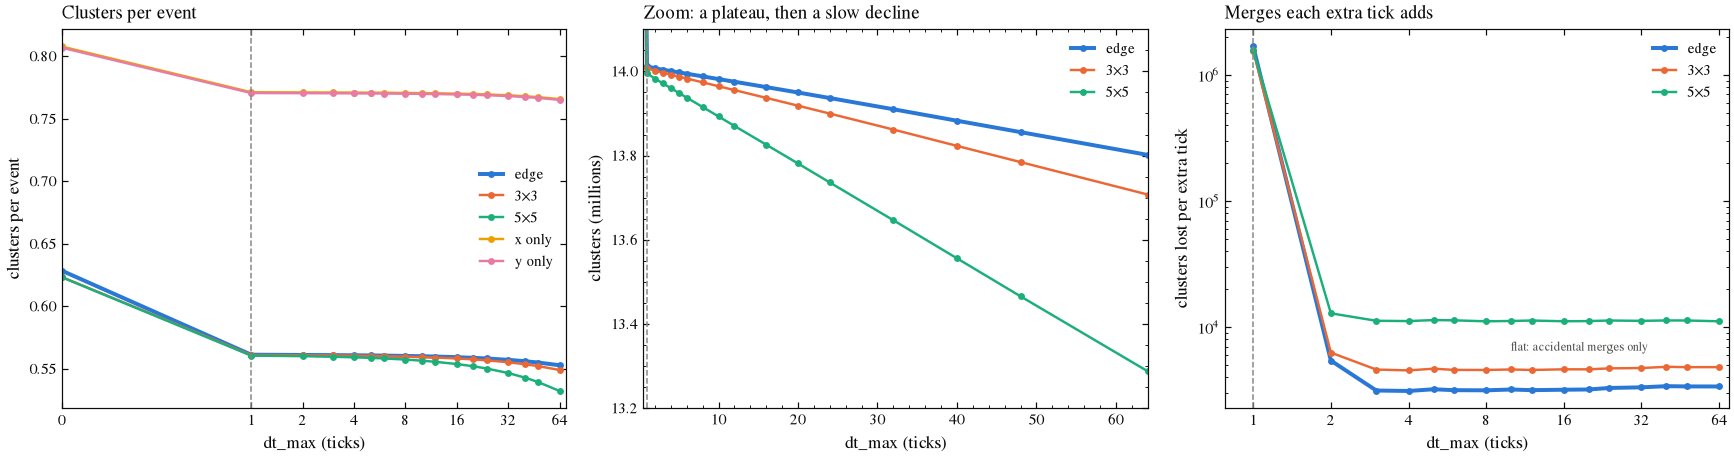

edge     : dt 0 -> 1 merges 1,681,399; dt 1 -> 2 merges 5,426 (≈ 2,250 real + 3,176 accidental); every further tick: 3,176
3×3      : dt 0 -> 1 merges 1,559,443; dt 1 -> 2 merges 6,277 (≈ 1,677 real + 4,600 accidental); every further tick: 4,600


In [7]:
@numba.njit(cache=True)
def _link_any(x, y, t, tf, dt, dtf, offsets, parent, latest, lo, hi):
    # kronos.cluster._link for any neighborhood, with an optional fine-time cut dtf.
    height, width = latest.shape
    for i in range(lo, hi):
        for k in range(len(offsets)):
            px, py = x[i] + offsets[k, 0], y[i] + offsets[k, 1]
            if 0 <= px < width and 0 <= py < height:
                j = latest[py, px]
                if lo <= j < i and t[i] - t[j] <= dt and abs(tf[i] - tf[j]) <= dtf:
                    a, b = _find(parent, i), _find(parent, j)
                    parent[max(a, b)] = min(a, b)
        latest[y[i], x[i]] = i


@numba.njit(parallel=True, cache=True)
def _label_any(x, y, t, tf, dt, dtf, offsets, width, height, n_slices):
    # kronos.cluster._label_sorted for any neighborhood: time slices in parallel, then the cuts.
    n = len(t)
    parent = np.arange(n)
    bounds = np.linspace(0, n, n_slices + 1).astype(np.int64)
    for s in numba.prange(n_slices):
        _link_any(x, y, t, tf, dt, dtf, offsets, parent, np.full((height, width), -1, np.int64), bounds[s], bounds[s + 1])
    latest = np.full((height, width), -1, np.int64)
    for s in range(1, n_slices):
        lo = hi = bounds[s]
        while lo > 0 and t[lo - 1] >= t[bounds[s]] - dt:
            lo -= 1
        while hi < n and t[hi] <= t[bounds[s] - 1] + dt:
            hi += 1
        _link_any(x, y, t, tf, dt, dtf, offsets, parent, latest, lo, hi)
    roots = np.empty(n, np.int64)
    for i in numba.prange(n):
        r = np.int64(i)
        while parent[r] != r:
            r = parent[r]
        roots[i] = r
    rank = np.cumsum(roots == np.arange(n)) - 1
    labels = np.empty(n, np.int64)
    for i in numba.prange(n):
        labels[i] = rank[roots[i]]
    return labels


SHAPES = {
    'edge': np.array([(0, 0), (1, 0), (-1, 0), (0, 1), (0, -1)]),
    '3×3': np.array([(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1)]),
    '5×5': np.array([(dx, dy) for dx in range(-2, 3) for dy in range(-2, 3)]),
    'x only': np.array([(-1, 0), (0, 0), (1, 0)]),
    'y only': np.array([(0, -1), (0, 0), (0, 1)]),
}
FINE_STEPS_PER_TICK = 128


def label(events, dt=None, shape='edge', fine_ns=None):
    # Cluster labels for a neighborhood and time window; fine_ns cuts on fine time instead of ticks.
    if fine_ns is None:
        return _label_any(
            events['x'], events['y'], events['toa'], events['toa'], dt, 1 << 60, SHAPES[shape], WIDTH, HEIGHT, 4 * numba.get_num_threads()
        )
    dtf = round(fine_ns / 25 * FINE_STEPS_PER_TICK)
    return _label_any(
        events['x'],
        events['y'],
        events['toa'],
        events['tf'],
        dtf // FINE_STEPS_PER_TICK + 2,
        dtf,
        SHAPES[shape],
        WIDTH,
        HEIGHT,
        4 * numba.get_num_threads(),
    )


print('same labels as kronos label_events:', np.array_equal(label(ev, CHOSEN_DT), label_events(ev['x'], ev['y'], ev['toa'], CHOSEN_DT)))

SWEEP_DT = [0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32, 40, 48, 64]
DOUBLE_TOT = (38, 75)  # summed ToT of two electrons in one cluster (section 4b)
rows = []
for shape in SHAPES:
    for dt in SWEEP_DT:
        labels = label(ev, dt, shape)
        size = np.bincount(labels)
        summed_tot = np.bincount(labels, ev['tot'])
        rows.append(
            {
                'shape': shape,
                'dt': dt,
                'clusters': len(size),
                'clusters_per_event': len(size) / n_events,
                'double_tot': np.mean((summed_tot >= DOUBLE_TOT[0]) & (summed_tot < DOUBLE_TOT[1])),
            }
        )
sweep = pd.DataFrame(rows)

fig, (ax_all, ax_zoom, ax_rate) = plt.subplots(1, 3, figsize=(16, 4.4))
for k, shape in enumerate(SHAPES):
    s = sweep[sweep['shape'] == shape]
    lw = 2.6 if shape == 'edge' else 1.6
    ax_all.plot(s.dt, s.clusters_per_event, marker='o', ms=3.5, lw=lw, color=SERIES[k], label=shape)
    if shape in ('edge', '3×3', '5×5'):
        ax_zoom.plot(s.dt, s.clusters / 1e6, marker='o', ms=3.5, lw=lw, color=SERIES[k], label=shape)
        ax_rate.plot(
            s.dt.to_numpy()[1:], -np.diff(s.clusters.to_numpy()) / np.diff(s.dt.to_numpy()), marker='o', ms=3.5, lw=lw, color=SERIES[k], label=shape
        )
for ax in (ax_all, ax_zoom, ax_rate):
    ax.axvline(CHOSEN_DT, color=MUTED, lw=1, ls='--')
for ax in (ax_all, ax_rate):
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xticks([0, 1, 2, 4, 8, 16, 32, 64], ['0', '1', '2', '4', '8', '16', '32', '64'])
    ax.minorticks_off()
ax_all.set(xlabel='dt_max (ticks)', ylabel='clusters per event', xlim=(0, 70), title='Clusters per event')
ax_all.legend()
ax_zoom.set(xlabel='dt_max (ticks)', ylabel='clusters (millions)', ylim=(13.2, 14.1), xlim=(0.5, 64), title='Zoom: a plateau, then a slow decline')
ax_zoom.legend()
ax_rate.set(yscale='log', xlabel='dt_max (ticks)', ylabel='clusters lost per extra tick', xlim=(0.9, 70), title='Merges each extra tick adds')
ax_rate.text(10, 6.5e3, 'flat: accidental merges only', fontsize=8, color=INK_2)
ax_rate.legend(loc='upper right')
plt.tight_layout()
plt.show()

for shape in ('edge', '3×3'):
    counts = sweep[sweep['shape'] == shape].set_index('dt').clusters
    slope = -np.polyfit(counts.loc[3:16].index, counts.loc[3:16].values, 1)[0]
    print(
        f'{shape:9s}: dt 0 -> 1 merges {counts[0] - counts[1]:,}; dt 1 -> 2 merges {counts[1] - counts[2]:,} (≈ {counts[1] - counts[2] - slope:,.0f} real + {slope:,.0f} accidental); every further tick: {slope:,.0f}'
    )

* **`dt = 0` is wrong.** Going to `dt = 1` merges ~1.6 M clusters (11 %): electrons whose pixels
  straddle a tick boundary or fire late.
* **From `dt = 1` on the count is a plateau** that loses a constant number of clusters per extra
  tick. A constant rate is the signature of accidental merges, which grow linearly with the window.
  The `1 → 2` step is only slightly bigger than that floor: a couple of thousand real late pixels.
* **Neighborhood:** `edge`, `3×3` and `5×5` sit within 0.1 % of each other at `dt = 1`. The bigger
  the neighborhood, the faster it loses clusters per tick (more pixels for an accidental hit to land
  on); `5×5` gains nothing real. `x only` and `y only` split a quarter of all
  electrons and are mirror images of each other.

### 4b. What the choices do to the clusters

A good rule leaves the physics alone: one peak of summed ToT per electron and a stable size mix.
Splitting makes low-ToT fragments; merging makes a second peak at twice the ToT of one electron.

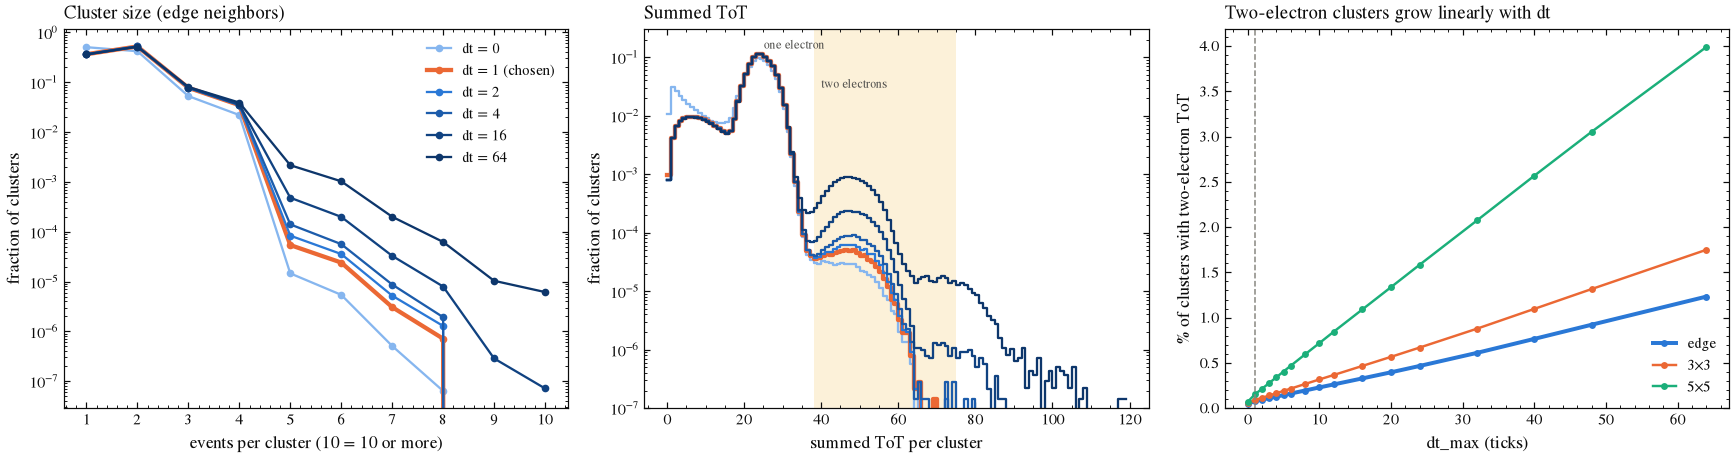

In [8]:
RAMP = ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281', '#0d366b']  # ordinal blue, light -> dark
fig, (ax_size, ax_tot, ax_double) = plt.subplots(1, 3, figsize=(16, 4.4))
tot_bins = np.arange(0, 121)
for k, dt in enumerate([0, 1, 2, 4, 16, 64]):
    labels = label(ev, dt)
    size = np.bincount(labels)
    lw, color = (2.8, ORANGE) if dt == CHOSEN_DT else (1.5, RAMP[k])
    name = f'dt = {dt}' + (' (chosen)' if dt == CHOSEN_DT else '')
    ax_size.plot(np.arange(1, 11), np.bincount(np.minimum(size, 10), minlength=11)[1:] / len(size), marker='o', ms=4, lw=lw, color=color, label=name)
    ax_tot.step(tot_bins[:-1], np.histogram(np.bincount(labels, ev['tot']), tot_bins)[0] / len(size), where='post', lw=lw, color=color, label=name)
ax_size.set(
    yscale='log',
    xlabel='events per cluster (10 = 10 or more)',
    ylabel='fraction of clusters',
    title='Cluster size (edge neighbors)',
    xticks=range(1, 11),
)
ax_size.legend()
ax_tot.axvspan(*DOUBLE_TOT, color=YELLOW, alpha=0.15, lw=0)
ax_tot.text(DOUBLE_TOT[0] + 2, 3e-2, 'two electrons', fontsize=8, color=INK_2)
ax_tot.text(25, 1.4e-1, 'one electron', fontsize=8, color=INK_2)
ax_tot.set(yscale='log', ylim=(1e-7, 0.3), xlabel='summed ToT per cluster', ylabel='fraction of clusters', title='Summed ToT')
for shape in ('edge', '3×3', '5×5'):
    s = sweep[sweep['shape'] == shape]
    ax_double.plot(
        s.dt, 100 * s.double_tot, marker='o', ms=3.5, lw=2.6 if shape == 'edge' else 1.6, color=SERIES[list(SHAPES).index(shape)], label=shape
    )
ax_double.axvline(CHOSEN_DT, color=MUTED, lw=1, ls='--')
ax_double.set(
    xlabel='dt_max (ticks)', ylabel='% of clusters with two-electron ToT', title='Two-electron clusters grow linearly with dt', ylim=(0, None)
)
ax_double.legend()
plt.tight_layout()
plt.show()

From `dt = 1` up, the size mix and the one-electron peak barely move. Only the two-electron bump
grows, linearly with the window: accidental merges. It does not vanish at `dt = 0`, because two
electrons on neighboring pixels in the same tick cannot be told apart by any time cut.

## 5. Why at least one tick: timewalk

A pixel's `toa` is when its signal crosses threshold, and small signals cross later (*timewalk*).
Cluster generously (`dt = 8`, 3 × 3) and ask when each pixel fires relative to its cluster, against
its own ToT:

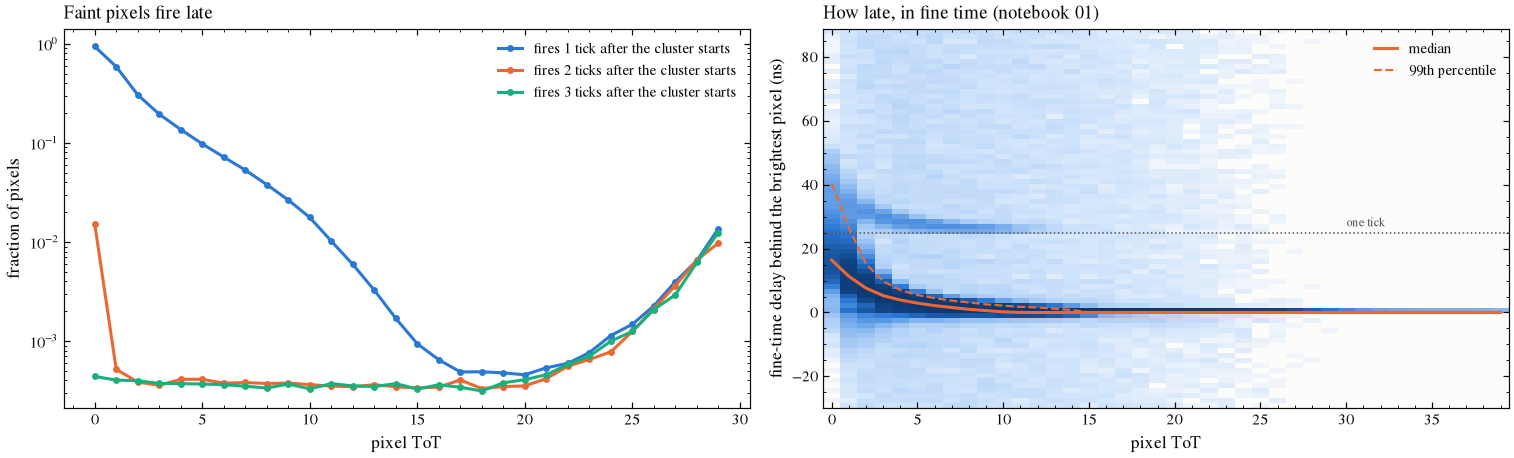

In [9]:
labels = label(ev, 8, '3×3')
size = np.bincount(labels)
first_index = np.flatnonzero(np.r_[True, labels[1:] > np.maximum.accumulate(labels)[:-1]])
delay = ev['toa'] - ev['toa'][first_index][labels]
multi = size[labels] >= 2
order = np.lexsort((-ev['tot'], labels))
brightest = np.empty(len(size), np.int64)
is_first = np.r_[True, labels[order][1:] != labels[order][:-1]]
brightest[labels[order][is_first]] = order[is_first]
fine_delay = (ev['tf'] - ev['tf'][brightest[labels]]) * 25 / FINE_STEPS_PER_TICK  # ns

fig, (ax_frac, ax_fine) = plt.subplots(1, 2, figsize=(14, 4.4))
tot_axis = np.arange(0, 41)
for d, color in zip([1, 2, 3], [BLUE, ORANGE, '#1baf7a']):
    frac = [np.mean(delay[multi & (ev['tot'] == v)] == d) if np.sum(multi & (ev['tot'] == v)) > 2000 else np.nan for v in tot_axis]
    ax_frac.plot(tot_axis, frac, marker='o', ms=3.5, lw=2, color=color, label=f'fires {d} tick{"s" * (d > 1)} after the cluster starts')
ax_frac.set(yscale='log', xlabel='pixel ToT', ylabel='fraction of pixels', title='Faint pixels fire late')
ax_frac.legend()
sel = multi & (ev['tot'] < 40)
h2, xe, ye = np.histogram2d(ev['tot'][sel], fine_delay[sel], bins=(np.arange(0, 41) - 0.5, np.arange(-30, 90.1, 1.5625)))
ax_fine.imshow(np.maximum(h2.T, 1), origin='lower', aspect='auto', cmap=SEQUENTIAL, norm=LogNorm(), extent=(xe[0], xe[-1], ye[0], ye[-1]))
ax_fine.plot(tot_axis[:-1], [np.median(fine_delay[sel & (ev['tot'] == v)]) for v in tot_axis[:-1]], color=ORANGE, lw=2, label='median')
ax_fine.plot(
    tot_axis[:-1],
    [np.percentile(fine_delay[sel & (ev['tot'] == v)], 99) for v in tot_axis[:-1]],
    color=ORANGE,
    lw=1.4,
    ls='--',
    label='99th percentile',
)
ax_fine.axhline(25, color=INK_2, lw=1, ls=':')
ax_fine.text(30, 27, 'one tick', fontsize=8, color=INK_2)
ax_fine.set(xlabel='pixel ToT', ylabel='fine-time delay behind the brightest pixel (ns)', title='How late, in fine time (notebook 01)')
ax_fine.grid(False)
ax_fine.legend(loc='upper right')
plt.tight_layout()
plt.show()

Nearly every ToT-0 pixel and ~30 % of ToT-2 pixels land one tick after their cluster starts; bright
pixels almost never do. Faint pixels trail by up to ~16 ns (right), so an electron that hits late in
a tick spills into the next one. **That is why `dt_max` must be at least 1.** Two ticks late is a real
effect only for the faintest pixels; the flat floor shared with "three ticks late" is accidental
merges in these generous clusters.

## 6. An error budget with a known answer

To weigh split electrons against merged ones, we need numbers for both. Real data has no ground
truth, so make some: cut the sample into time slices and **overlay** them (shift each slice to start
at the same `toa`). Events from different slices are unrelated by construction, so a cluster that
mixes slices is an accidental merge that can be counted exactly.

* **Merged electrons:** overlaying two halves of the run meets every cluster with an independent stream
  as dense as its own: `merge rate = (clusters in the halves alone − clusters in the overlay) /
  clusters alone`. That is the accidental merge rate at the real flux.
* **Split electrons:** clusters + merged − the true number of electrons, which is that same sum on the
  plateau of wide windows (`dt` 3–8), where nothing is split.

Overlaying 4, 8 or 16 slices does the same at 4–16 times the flux. (Overlays slightly overstate
merges: a real second electron finds pixels still busy from the first, an overlaid one does not.)

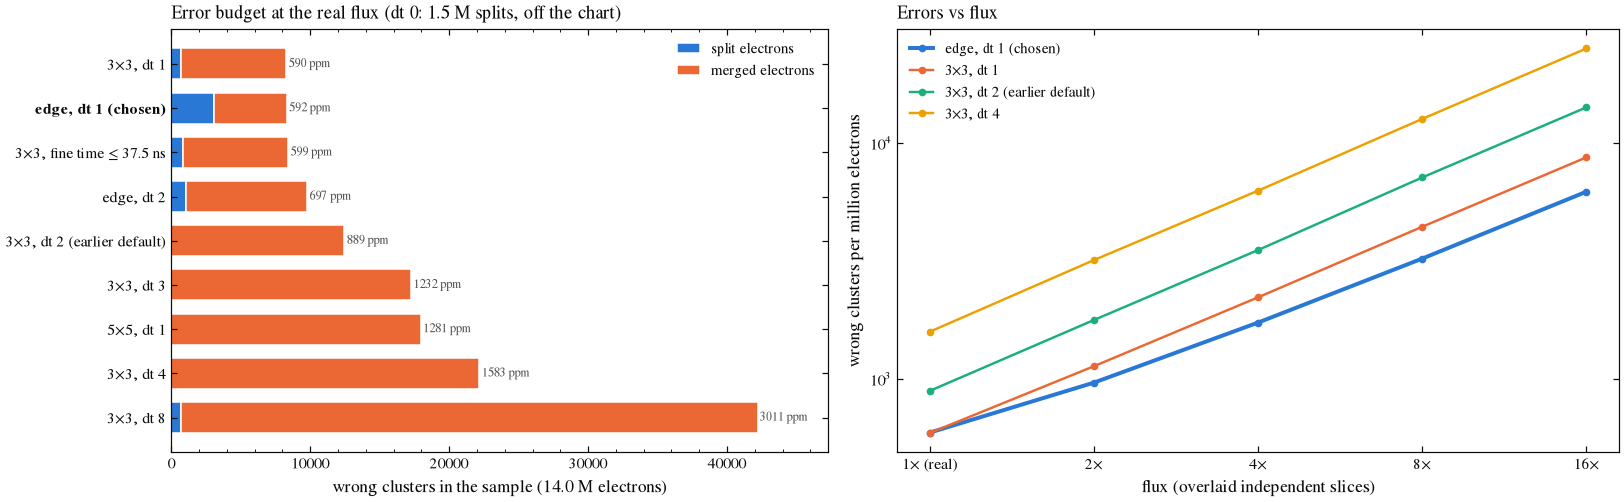

,clusters,split,merged,wrong per million
rule,,,,
"3×3, dt 1",14007692,668,7597,590
"edge, dt 1 (chosen)",14012437,3058,5242,592
"3×3, fine time ≤ 37.5 ns",14007845,813,7589,599
"edge, dt 2",14007011,1082,8692,697
"3×3, dt 2 (earlier default)",14001415,0,12463,889
"3×3, dt 3",13996808,0,17262,1232
"5×5, dt 1",13995463,0,17957,1281
"3×3, dt 4",13992271,0,22181,1583
"3×3, dt 8",13973868,721,41474,3011


In [10]:
def overlay(events, n_slices):
    # Overlay n_slices equal time slices of events: (overlay, [each slice on its own]).
    t = events['toa']
    edges = np.linspace(t[0], t[-1] + 1, n_slices + 1).astype(np.int64)
    which = np.searchsorted(edges, t, side='right') - 1
    shift = edges[which] - edges[0]
    order = np.argsort(t - shift, kind='stable')
    stacked = {name: values[order] for name, values in events.items()}
    stacked['toa'] = (t - shift)[order]
    stacked['tf'] = (events['tf'] - FINE_STEPS_PER_TICK * shift)[order]
    return stacked, [{name: values[which == s] for name, values in events.items()} for s in range(n_slices)]


def merge_rate(stacked, slices, **rule):
    alone = sum(label(s, **rule)[-1] + 1 for s in slices)
    return alone, (alone - (label(stacked, **rule)[-1] + 1)) / alone


RULES = {
    '3×3, dt 0': {'dt': 0, 'shape': '3×3'},
    '3×3, dt 1': {'dt': 1, 'shape': '3×3'},
    '3×3, dt 2 (earlier default)': {'dt': 2, 'shape': '3×3'},
    '3×3, dt 3': {'dt': 3, 'shape': '3×3'},
    '3×3, dt 4': {'dt': 4, 'shape': '3×3'},
    '3×3, dt 8': {'dt': 8, 'shape': '3×3'},
    'edge, dt 1 (chosen)': {'dt': 1},
    'edge, dt 2': {'dt': 2},
    '5×5, dt 1': {'dt': 1, 'shape': '5×5'},
    '3×3, fine time ≤ 37.5 ns': {'fine_ns': 37.5, 'shape': '3×3'},
}
halves, half_slices = overlay(ev, 2)
budget = []
for name, rule in RULES.items():
    clusters, rate_1x = merge_rate(halves, half_slices, **rule)
    budget.append({'rule': name, 'clusters': clusters, 'merge_rate': rate_1x, 'merged': rate_1x * clusters})
budget = pd.DataFrame(budget).set_index('rule')
electrons = (budget.clusters + budget.merged).loc[['3×3, dt 3', '3×3, dt 4', '3×3, dt 8']].mean()
budget['split'] = (budget.clusters + budget.merged - electrons).clip(lower=0)
budget['wrong per million'] = (budget.split + budget.merged) / electrons * 1e6
del halves, half_slices

FLUX = [2, 4, 8, 16]
flux_rules = {name: RULES[name] for name in ('edge, dt 1 (chosen)', '3×3, dt 1', '3×3, dt 2 (earlier default)', '3×3, dt 4')}
flux_rows = []
for k in FLUX:
    keep = ev['toa'] < np.linspace(ev['toa'][0], ev['toa'][-1] + 1, 17).astype(np.int64)[k]  # the first k of 16 slices
    stacked, slices = overlay({name: values[keep] for name, values in ev.items()}, k)
    for name, rule in flux_rules.items():
        flux_rows.append({'flux': k, 'rule': name, 'cross_rate': merge_rate(stacked, slices, **rule)[1]})
flux = pd.DataFrame(flux_rows)
del stacked, slices

fig, (ax_budget, ax_flux) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={'width_ratios': [1, 1.1]})
shown = budget.drop(index='3×3, dt 0').sort_values('wrong per million', ascending=False)
ypos = np.arange(len(shown))
ax_budget.barh(ypos, shown.split, color=BLUE, height=0.7, label='split electrons', edgecolor=SURFACE)
ax_budget.barh(ypos, shown.merged, left=shown.split, color=ORANGE, height=0.7, label='merged electrons', edgecolor=SURFACE)
for y_, (name, row) in zip(ypos, shown.iterrows()):
    ax_budget.text(row.split + row.merged + 150, y_, f'{row["wrong per million"]:.0f} ppm', va='center', fontsize=8, color=INK_2)
ax_budget.set_yticks(ypos, shown.index)
for tick in ax_budget.get_yticklabels():
    if 'chosen' in tick.get_text():
        tick.set_fontweight('bold')
ax_budget.set(
    xlabel=f'wrong clusters in the sample ({electrons / 1e6:.1f} M electrons)',
    title='Error budget at the real flux (dt 0: 1.5 M splits, off the chart)',
)
ax_budget.set_xlim(right=(shown.split + shown.merged).max() * 1.12)  # room for the ppm labels
ax_budget.yaxis.minorticks_off()
ax_budget.legend(loc='upper right')
for i, name in enumerate(flux_rules):
    base, split_rate = budget.loc[name, 'merge_rate'], budget.loc[name, 'split'] / electrons
    total = np.r_[base, flux[flux.rule == name].cross_rate + base] + split_rate  # own accidentals + the other copies
    ax_flux.plot([1] + FLUX, 1e6 * total, marker='o', ms=4, lw=2.6 if 'chosen' in name else 1.6, color=SERIES[i], label=name)
ax_flux.set(
    xscale='log',
    yscale='log',
    xticks=[1] + FLUX,
    xticklabels=['1× (real)'] + [f'{k}×' for k in FLUX],
    xlabel='flux (overlaid independent slices)',
    ylabel='wrong clusters per million electrons',
    title='Errors vs flux',
)
ax_flux.minorticks_off()
ax_flux.legend()
plt.tight_layout()
plt.show()
budget[['clusters', 'split', 'merged', 'wrong per million']].round(0).astype(int).sort_values('wrong per million')

Unless a rule is clearly wrong, it gets fewer than 0.1 % of clusters wrong at the real flux. Merges
dominate, and merges grow with flux, so the narrower rules win more the higher the dose rate:

* **`dt = 1` vs `dt = 2`:** one tick less gives up ~1 000 late faint pixels (split electrons) and
  avoids ~5 000 accidental merges.
* **Edge neighbors vs the 3 × 3 square** (both `dt = 1`): dropping the diagonals splits ~2 400 more
  electrons and avoids about as many merges, a tie at the real flux. At higher flux edge neighbors
  make the fewest errors of all.
* **Radius 2** only adds merges. **A fine-time cut** (37.5 ns, notebook 01's decoded fine time) ties
  with `dt = 1`: the timewalk tail of faint pixels (section 5) is about one tick long, so a finer clock
  cannot narrow the window without splitting electrons.

The split estimates are good to about ±1 000 (the scatter of the plateau estimate).

## 7. The clusters that change

A wider window or neighborhood only ever *merges* clusters of the narrower one, so we can pick out
the clusters a change joins and look at them. Pixels are colored by their cluster under the narrower
rule, with ToT and the `toa` offset written in.

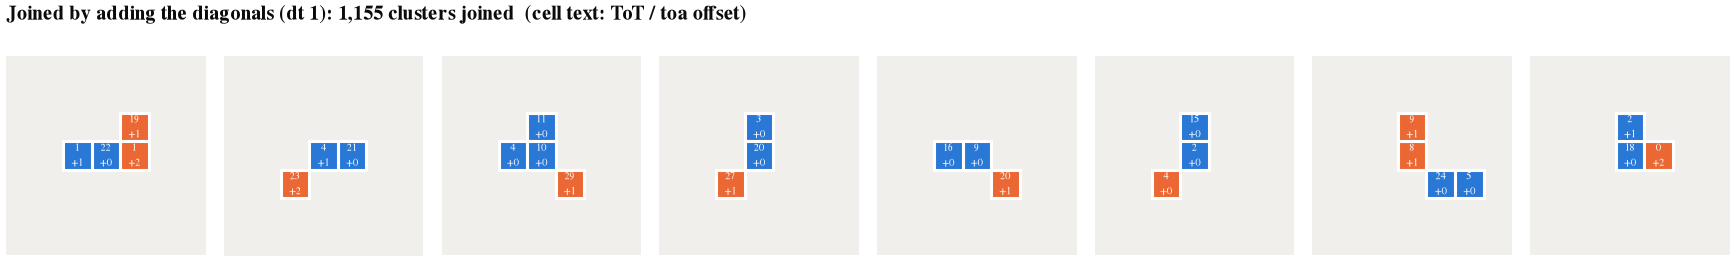

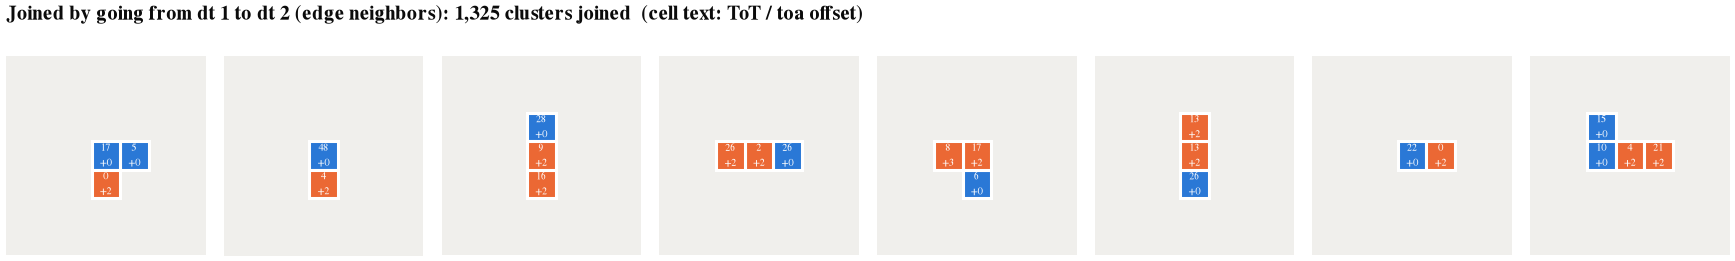

2-pixel clusters (3 x 3, dt 1): horizontal 3,652,346, vertical 3,667,907, diagonal only 1,860


In [11]:
def gallery(small, large, title, events, n_examples=8, seed=1):
    # Draw clusters of the wider rule (large) that hold more than one cluster of the narrower rule (small).
    pairs = np.unique(np.c_[large, small], axis=0)
    joined = np.flatnonzero(np.bincount(pairs[:, 0], minlength=large.max() + 1) > 1)
    picks = np.random.default_rng(seed).choice(joined, n_examples, replace=False)
    fig, axes = plt.subplots(1, n_examples, figsize=(16, 2.5))
    for ax, p in zip(axes, picks):
        idx = np.flatnonzero(large == p)
        cx, cy = np.median(events['x'][idx]).round(), np.median(events['y'][idx]).round()
        pieces = {piece: k for k, piece in enumerate(np.unique(small[idx]))}
        t0 = events['toa'][idx].min()
        for i in idx:
            ax.add_patch(
                Rectangle(
                    (events['x'][i] - cx - 0.5, events['y'][i] - cy - 0.5), 1, 1, color=SERIES[pieces[small[i]] % len(SERIES)], ec=SURFACE, lw=2
                )
            )
            ax.text(
                events['x'][i] - cx,
                events['y'][i] - cy,
                f'{events["tot"][i]}\n+{events["toa"][i] - t0}',
                ha='center',
                va='center',
                fontsize=6.5,
                color='white',
            )
        ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), aspect='equal')
        no_grid(ax)
        ax.set_facecolor(PANEL)
    fig.suptitle(f'{title}: {len(joined):,} clusters joined  (cell text: ToT / toa offset)', x=0.01, ha='left', fontweight='bold')
    plt.tight_layout()
    plt.show()


window = {name: values[:6_000_000] for name, values in ev.items()}  # a few million events are plenty for examples
edge_1, box_1, edge_2 = label(window, 1), label(window, 1, '3×3'), label(window, 2)
gallery(edge_1, box_1, 'Joined by adding the diagonals (dt 1)', window)
gallery(edge_1, edge_2, 'Joined by going from dt 1 to dt 2 (edge neighbors)', window)

labels = label(ev, CHOSEN_DT, '3×3')
by_cluster = np.argsort(labels, kind='stable')
pairs = np.flatnonzero(np.bincount(labels) == 2)
a = by_cluster[np.searchsorted(labels[by_cluster], pairs)]
b = by_cluster[np.searchsorted(labels[by_cluster], pairs) + 1]
dx, dy = abs(ev['x'][a] - ev['x'][b]), abs(ev['y'][a] - ev['y'][b])
print(
    f'2-pixel clusters (3 x 3, dt 1): horizontal {np.sum((dx == 1) & (dy == 0)):,}, vertical {np.sum((dx == 0) & (dy == 1)):,}, diagonal only {np.sum((dx == 1) & (dy == 1)):,}'
)

* **Adding the diagonals** joins a mix: sometimes a faint corner pixel of one electron (a correct join
  the edge rule misses), sometimes two complete electrons (ToT ~20–30 each) touching at a corner (an
  accidental merge the edge rule avoids). Diagonal-only pairs are about 1 in 4 000 two-pixel clusters:
  diagonal pixels almost always come with the edge pixel between them. Horizontal and vertical pairs
  are equally common.
* **Going from `dt = 1` to `dt = 2`** is also a mix: a faint pixel two ticks after a complete electron
  (correct), or two complete electrons next to each other two ticks apart (accidental).

Both changes trade a few real joins for about as many false ones, as the error budget says.

## 8. Speed

Accuracy hardly separates the reasonable rules, so speed matters. Every event looks up each pixel of
its neighborhood, and the time window adds no work of its own. Three measurements: labeling speed for
each neighborhood and window, how labeling scales with cores, and where the time goes in the full
pipeline (sort + cluster, all 85 M events). Off-the-shelf DBSCAN with a Chebyshev metric on
`(x, y, toa/dt_max)` defines exactly the 3 × 3 clusters, so it serves as a reference.

DBSCAN: 1.2 M events/s, same clusters as the 3 x 3 rule: True


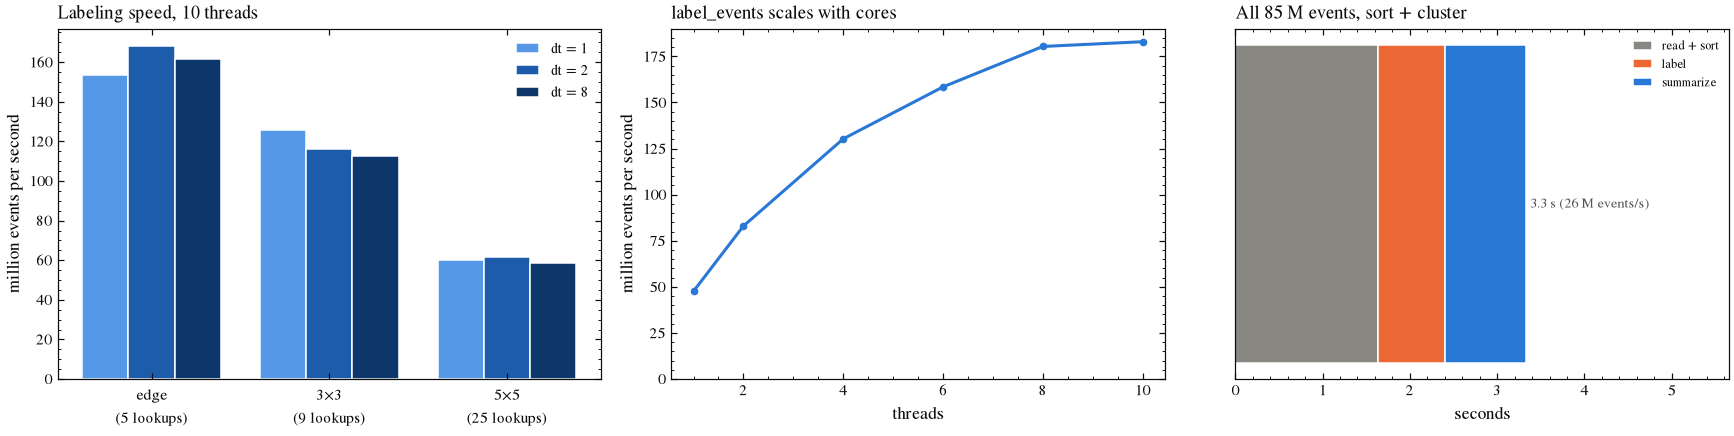

DBSCAN for comparison: 1.2 M events/s, 150× slower than label_events


dt,1,2,8
shape,,,
3×3,126.0,116.0,113.0
5×5,60.0,62.0,58.0
edge,154.0,168.0,162.0


In [12]:
for name in ['H', 'g', 'labels', 'delay', 'fine_delay', 'order', 'multi', 'sel', 'window', 'edge_1', 'box_1', 'edge_2', 'by_cluster', 'beam', 'rate']:
    globals().pop(name, None)
gc.collect()  # free the analysis arrays so the timings are not slowed by swapping

shape_speed = []
for shape in ('edge', '3×3', '5×5'):
    for dt in (1, 2, 8):
        times = []
        for _ in range(3):
            start = time.perf_counter()
            label(ev, dt, shape)
            times.append(time.perf_counter() - start)
        shape_speed.append({'shape': shape, 'dt': dt, 'M events/s': n_events / min(times) / 1e6})
shape_speed = pd.DataFrame(shape_speed)

threads = [t for t in (1, 2, 4, 6, 8, 10, 12, 16) if t <= numba.config.NUMBA_NUM_THREADS]
scaling = {}
for n_threads in threads:
    numba.set_num_threads(n_threads)
    times = []
    for _ in range(5):
        start = time.perf_counter()
        label_events(ev['x'], ev['y'], ev['toa'], CHOSEN_DT)
        times.append(time.perf_counter() - start)
    scaling[n_threads] = n_events / min(times) / 1e6
numba.set_num_threads(numba.config.NUMBA_NUM_THREADS)

n_db = 300_000
X_db = np.c_[ev['x'][:n_db], ev['y'][:n_db], (ev['toa'][:n_db] - ev['toa'][0]) / PREVIOUS_DT].astype(float)
start = time.perf_counter()
db = DBSCAN(eps=1.0, min_samples=1, metric='chebyshev').fit(X_db).labels_
dbscan_speed = n_db / (time.perf_counter() - start) / 1e6
ours = label({name: values[:n_db] for name, values in ev.items()}, PREVIOUS_DT, '3×3')
print(
    f'DBSCAN: {dbscan_speed:.1f} M events/s, same clusters as the 3 x 3 rule: {len(np.unique(np.c_[db, ours], axis=0)) == len(np.unique(db)) == len(np.unique(ours))}'
)

spent = {'read + sort': 0.0, 'label': 0.0, 'summarize': 0.0}
n_all = 0
tic = time.perf_counter()
for part in merge_sort(files):
    spent['read + sort'] += time.perf_counter() - tic
    tic = time.perf_counter()
    labels = label_events(part['x'], part['y'], part['toa'], CHOSEN_DT)
    spent['label'] += time.perf_counter() - tic
    tic = time.perf_counter()
    summarize_clusters(part, labels)
    spent['summarize'] += time.perf_counter() - tic
    n_all += len(part['toa'])
    tic = time.perf_counter()

fig, (ax_shape, ax_scale, ax_e2e) = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1.1, 1, 1]})
for k, dt in enumerate((1, 2, 8)):
    s = shape_speed[shape_speed.dt == dt]
    ax_shape.bar(np.arange(3) + (k - 1) * 0.26, s['M events/s'], width=0.26, color=RAMP[2 * k + 1], label=f'dt = {dt}', edgecolor=SURFACE)
ax_shape.set_xticks(range(3), ['edge\n(5 lookups)', '3×3\n(9 lookups)', '5×5\n(25 lookups)'])
ax_shape.set(ylabel='million events per second', title=f'Labeling speed, {numba.config.NUMBA_NUM_THREADS} threads')
ax_shape.xaxis.minorticks_off()
ax_shape.legend()
ax_scale.plot(threads, [scaling[t] for t in threads], marker='o', ms=4, lw=2, color=BLUE)
ax_scale.set(xlabel='threads', ylabel='million events per second', title='label_events scales with cores', ylim=(0, None))
left = 0.0
for k, (step, seconds) in enumerate(spent.items()):
    ax_e2e.barh([0], [seconds], left=left, color=[MUTED, ORANGE, BLUE][k], height=0.5, label=step, edgecolor=SURFACE)
    left += seconds
ax_e2e.text(left + 0.05, 0, f'{left:.1f} s ({n_all / left / 1e6:.0f} M events/s)', va='center', fontsize=9, color=INK_2)
ax_e2e.set(xlabel='seconds', yticks=[], xlim=(0, left * 1.7), title=f'All {n_all / 1e6:.0f} M events, sort + cluster')
ax_e2e.yaxis.minorticks_off()
ax_e2e.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
print(f'DBSCAN for comparison: {dbscan_speed:.1f} M events/s, {scaling[threads[-1]] / dbscan_speed:.0f}× slower than label_events')
shape_speed.pivot(index='shape', columns='dt', values='M events/s').round(0)

* **Neighborhood:** the more lookups, the slower. Edge neighbors label somewhat faster than the 3 × 3
  square, and 5 × 5 runs at half the speed. Memory access, not arithmetic, sets the pace, so 9 lookups
  cost less than twice 5.
* **Time window:** no cost of its own; the differences between windows are run-to-run noise.
* **Cores:** labeling scales from ~50 M events/s on one thread to ~190 M events/s on all of them.
* **The whole pipeline:** reading and sorting take more than half of the time, and labeling plus
  summarizing the rest. Clustering is no longer the bottleneck.
* **DBSCAN** finds the same clusters two orders of magnitude slower: the speed comes from using the
  time order, not from the clustering rule.

## 9. Where we landed

| choice | tried | chosen | why |
|---|---|---|---|
| neighborhood | edge, 3 × 3, 5 × 5, one axis | **own pixel + 4 edge neighbors** | Charge reaches only the nearest pixels (§3), and diagonal pixels almost never come without the edge pixel between them (1 in 4 000 pairs, §7). Same accuracy as 3 × 3 at the real flux (592 vs 590 wrong per million), fewer errors at higher flux (~0.6 % vs 0.9 % at 16×), and the fastest. 5 × 5 only adds merges at half the speed; one axis splits a quarter of the electrons. |
| time window | 0 – 64 ticks | **`dt_max = 1`** | `dt = 0` splits 11 % of electrons (timewalk across tick edges, §5). Real pairs end after 1–2 ticks (§3), and every extra tick adds only accidental merges (§4, §6). `dt = 2` costs ~0.03 % more wrong clusters, and more at higher flux. |
| fine time | 25–50 ns cuts | **not used** | The timewalk tail is about one tick long, so a fine cut ties with `dt_max = 1` (§6). |
| algorithm | DBSCAN, one thread | **one pass, union-find, time slices on all cores** | Same clusters as DBSCAN, over 100× faster; scales with cores; sorting is now the slower step (§8). |

What no rule can fix: two electrons landing on neighboring pixels in the same tick end up in one
cluster (~0.05 % of clusters at this flux). They show up with twice the summed ToT of one electron
(38–75 ticks) and five or more pixels, so they can be flagged downstream.

With the clusters defined, notebook 03 asks where in its cluster each electron landed.